In [ ]:
!pip install catboost

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
import xgboost as xgb

from catboost import CatBoostClassifier
!pip install optuna
import optuna
import shap

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    f1_score,
    precision_recall_curve,
    confusion_matrix
)
from scipy.optimize import minimize

# Suppress non-critical logs and set reproducibility seeds
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

print("Environment setup complete. Core modeling, optimization, and SHAP libraries loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 11.1 MB/s eta 0:00:00
Environment setup complete. Core modeling, optimization, and SHAP libraries loaded.


## Model 1 — LightGBM 5-Fold Cross-Validation

In [ ]:
train_df = pd.read_csv('/content/train_engineered.csv')
test_df = pd.read_csv('/content/test_engineered.csv')

# Dynamically infer the target column
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

target_candidate_cols = list(train_cols - test_cols)

if len(target_candidate_cols) == 1:
    TARGET_COL = target_candidate_cols[0]
    print(f"Inferred target column: {TARGET_COL}")
elif 'target' in train_df.columns:
    TARGET_COL = 'target'
    print(f"Using default target column: {TARGET_COL}")
else:
    raise ValueError("Could not infer a single target column from train_df vs test_df. Please specify target column name.")

X = train_df.drop(TARGET_COL, axis=1)
y = train_df[TARGET_COL]
X_test = test_df.copy() # Test set typically contains only features

# Drop 'customer_id' column if it exists in features, as it's an identifier and not a numerical feature
if 'customer_id' in X.columns:
    X = X.drop('customer_id', axis=1)
if 'customer_id' in X_test.columns:
    X_test = X_test.drop('customer_id', axis=1)

N_SPLITS = 5 # Number of folds for StratifiedKFold
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_lgb = np.zeros(len(train_df))
test_lgb = np.zeros(len(test_df))

lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'min_child_samples': 20,
    'random_state': SEED,
    'verbose': -1,
    'n_estimators': 1000
}

fold_aucs_lgb = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    val_probs = model_lgb.predict_proba(X_val)[:, 1]
    oof_lgb[val_idx] = val_probs
    test_lgb += model_lgb.predict_proba(X_test)[:, 1] / N_SPLITS

    fold_auc = roc_auc_score(y_val, val_probs)
    fold_aucs_lgb.append(fold_auc)
    print(f"LightGBM Fold {fold + 1} ROC-AUC: {fold_auc:.5f}")

print(f"\nOverall LightGBM OOF ROC-AUC: {roc_auc_score(y, oof_lgb):.5f}")

Inferred target column: churn
LightGBM Fold 1 ROC-AUC: 0.80766
LightGBM Fold 2 ROC-AUC: 0.80162
LightGBM Fold 3 ROC-AUC: 0.81429
LightGBM Fold 4 ROC-AUC: 0.81296
LightGBM Fold 5 ROC-AUC: 0.80954

Overall LightGBM OOF ROC-AUC: 0.80922


## Model 2 — XGBoost 5-Fold Cross-Validation

In [ ]:
oof_xgb = np.zeros(len(train_df))
test_xgb = np.zeros(len(test_df))

# Compute class imbalance ratio (12,000 dataset has ~24.7% positive churn rate)
scale_pos_weight = (len(y) - y.sum()) / y.sum()

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': 0.03,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': 1.0,  # Adjusted to optimize ROC-AUC probabilistic ranking
    'random_state': SEED,
    'n_estimators': 1000,
    'tree_method': 'hist'
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model_xgb = xgb.XGBClassifier(**xgb_params)
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_probs = model_xgb.predict_proba(X_val)[:, 1]
    oof_xgb[val_idx] = val_probs
    test_xgb += model_xgb.predict_proba(X_test)[:, 1] / N_SPLITS
    print(f"XGBoost Fold {fold + 1} ROC-AUC: {roc_auc_score(y_val, val_probs):.5f}")

print(f"\nOverall XGBoost OOF ROC-AUC: {roc_auc_score(y, oof_xgb):.5f}")

XGBoost Fold 1 ROC-AUC: 0.80249
XGBoost Fold 2 ROC-AUC: 0.79905
XGBoost Fold 3 ROC-AUC: 0.80601
XGBoost Fold 4 ROC-AUC: 0.80477
XGBoost Fold 5 ROC-AUC: 0.80560

Overall XGBoost OOF ROC-AUC: 0.80350


## Model 3 — CatBoost 5-Fold Cross-Validation

In [ ]:
oof_cat = np.zeros(len(train_df))
test_cat = np.zeros(len(test_df))

cat_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': 0.04,
    'depth': 6,
    'random_seed': SEED,
    'iterations': 1000,
    'verbose': False
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model_cat = CatBoostClassifier(**cat_params)
    model_cat.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50,
        verbose=False
    )

    val_probs = model_cat.predict_proba(X_val)[:, 1]
    oof_cat[val_idx] = val_probs
    test_cat += model_cat.predict_proba(X_test)[:, 1] / N_SPLITS
    print(f"CatBoost Fold {fold + 1} ROC-AUC: {roc_auc_score(y_val, val_probs):.5f}")

print(f"\nOverall CatBoost OOF ROC-AUC: {roc_auc_score(y, oof_cat):.5f}")

CatBoost Fold 1 ROC-AUC: 0.80599
CatBoost Fold 2 ROC-AUC: 0.80358
CatBoost Fold 3 ROC-AUC: 0.81608
CatBoost Fold 4 ROC-AUC: 0.81561
CatBoost Fold 5 ROC-AUC: 0.81469

Overall CatBoost OOF ROC-AUC: 0.81102


## Hyperparameter Optimization with Optuna

In [ ]:
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 0.95),
        'bagging_freq': 1,
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': SEED,
        'verbose': -1,
        'n_estimators': 600
    }

    cv_scores = []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(30, verbose=False)])
        probs = m.predict_proba(X_va)[:, 1]
        cv_scores.append(roc_auc_score(y_va, probs))

    return np.mean(cv_scores)

print("Starting Optuna hyperparameter study (20 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(f"Best Optuna Trial ROC-AUC: {study.best_value:.5f}")
print("Best LightGBM Parameters:")
for k, v in study.best_params.items():
    print(f" - {k}: {v}")

Starting Optuna hyperparameter study (20 trials)...
Best Optuna Trial ROC-AUC: 0.81232
Best LightGBM Parameters:
 - learning_rate: 0.016647388665128004
 - num_leaves: 16
 - max_depth: 4
 - feature_fraction: 0.5562047245667128
 - bagging_fraction: 0.7001889123696711
 - min_child_samples: 63
 - reg_alpha: 0.067066375867523
 - reg_lambda: 0.00310875662486386


## Model Ensembling & Optimal Probability Blending

In [ ]:
# Optimize blend weights w1*LightGBM + w2*XGBoost + w3*CatBoost
def loss_func(weights):
    w1, w2, w3 = weights
    blend = (w1 * oof_lgb) + (w2 * oof_xgb) + (w3 * oof_cat)
    return -roc_auc_score(y, blend)

res = minimize(
    loss_func,
    [0.33, 0.33, 0.33],
    method='Nelder-Mead',
    bounds=[(0, 1), (0, 1), (0, 1)]
)

w1, w2, w3 = res.x / np.sum(res.x)  # Normalize weights
oof_ensemble = (w1 * oof_lgb) + (w2 * oof_xgb) + (w3 * oof_cat)
test_ensemble = (w1 * test_lgb) + (w2 * test_xgb) + (w3 * test_cat)

print("=" * 50)
print("             ENSEMBLE BLEND PERFORMANCE          ")
print("=" * 50)
print(f"LightGBM Weight: {w1:.3f} | OOF AUC: {roc_auc_score(y, oof_lgb):.5f}")
print(f"XGBoost Weight:  {w2:.3f} | OOF AUC: {roc_auc_score(y, oof_xgb):.5f}")
print(f"CatBoost Weight: {w3:.3f} | OOF AUC: {roc_auc_score(y, oof_cat):.5f}")
print("-" * 50)
print(f"ENSEMBLE OOF ROC-AUC SCORE: {roc_auc_score(y, oof_ensemble):.5f}")
print("=" * 50)

             ENSEMBLE BLEND PERFORMANCE          
LightGBM Weight: 0.282 | OOF AUC: 0.80922
XGBoost Weight:  0.121 | OOF AUC: 0.80350
CatBoost Weight: 0.597 | OOF AUC: 0.81102
--------------------------------------------------
ENSEMBLE OOF ROC-AUC SCORE: 0.81230


## Model Explainability — Global & Local SHAP Analysis

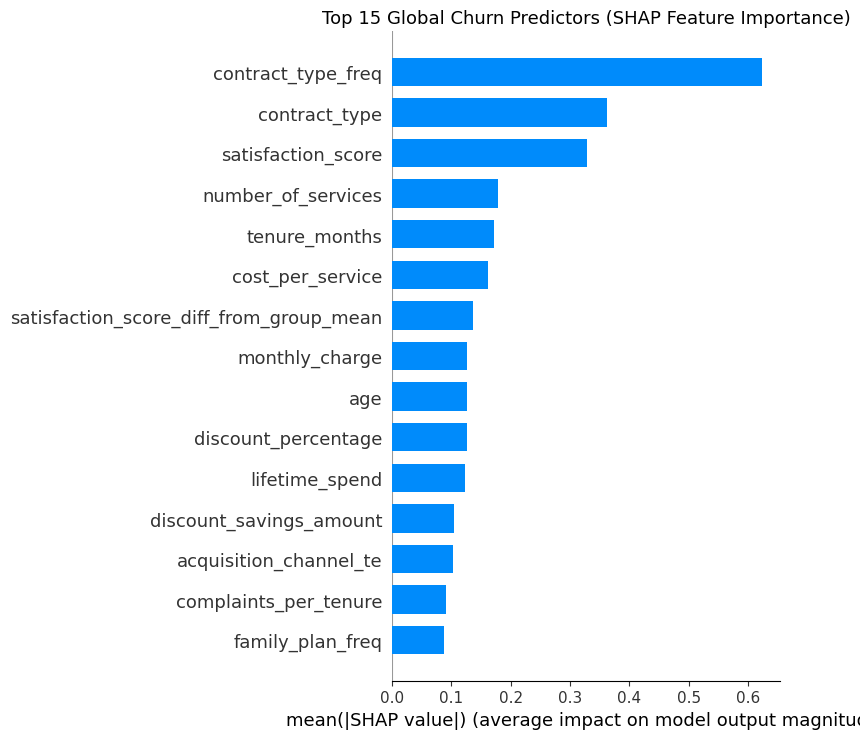

In [ ]:
explainer_model = lgb.LGBMClassifier(**lgb_params)
explainer_model.fit(X, y)

explainer = shap.TreeExplainer(explainer_model)
shap_values = explainer.shap_values(X)

# Handling binary LightGBM SHAP output formatting
if isinstance(shap_values, list):
    shap_vals = shap_values[2]
else:
    shap_vals = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X, plot_type="bar", max_display=15, show=False)
plt.title("Top 15 Global Churn Predictors (SHAP Feature Importance)", fontsize=13)
plt.tight_layout()
plt.show()

##Diagnostic Error & Residual Analysis

In [ ]:
preds_binary = (oof_ensemble >= 0.50).astype(int)

train_analysis = train_df.copy()
train_analysis['oof_prob'] = oof_ensemble
train_analysis['error_type'] = 'Correct'

train_analysis.loc[(y == 0) & (preds_binary == 1), 'error_type'] = 'False Positive (Over-predicted Churn)'
train_analysis.loc[(y == 1) & (preds_binary == 0), 'error_type'] = 'False Negative (Missed Churn)'

print("Error Class Breakdown:")
print(train_analysis['error_type'].value_counts())

# Inspect key friction metrics for missed churners (False Negatives)
fn_profile = train_analysis[train_analysis['error_type'] == 'False Negative (Missed Churn)'][
    ['tenure_months', 'monthly_charge', 'friction_score', 'satisfaction_score']
].mean()

tp_profile = train_analysis[(y == 1) & (preds_binary == 1)][
    ['tenure_months', 'monthly_charge', 'friction_score', 'satisfaction_score']
].mean()

df_errors = pd.DataFrame({'Missed Churners (FN)': fn_profile, 'Caught Churners (TP)': tp_profile})
print("\nProfile Comparison of Missed vs Caught Churners:")
display(df_errors)

Error Class Breakdown:
error_type
Correct                                  9557
False Negative (Missed Churn)            1913
False Positive (Over-predicted Churn)     530
Name: count, dtype: int64

Profile Comparison of Missed vs Caught Churners:


,Missed Churners (FN),Caught Churners (TP)
tenure_months,0.071615,-0.230677
monthly_charge,-0.008985,0.369029
friction_score,0.443283,1.280000
satisfaction_score,-0.123262,-0.881524


## Business Problem Solving — Optimal Decision Threshold Tuning

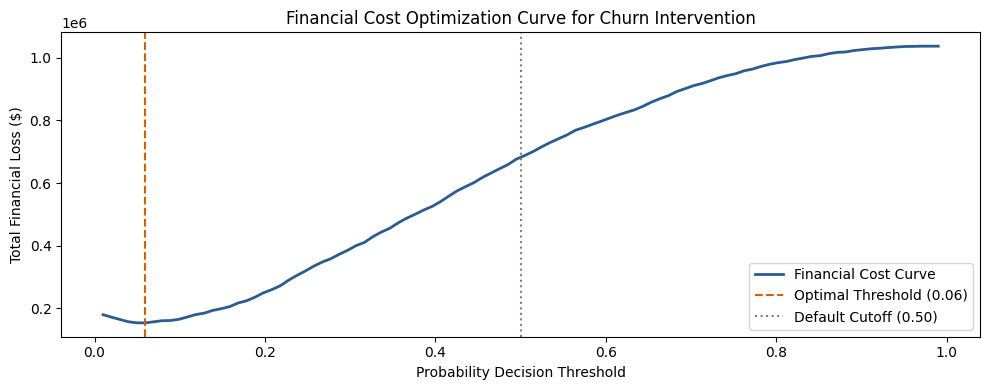

Optimal Decision Threshold: 0.06
Financial Cost at 0.50 Threshold: $680,150.00
Financial Cost at Optimal Threshold: $153,200.00
Net Financial Savings: $526,950.00


In [ ]:
# Financial Cost-Benefit Utility Function:
# - Cost of False Positive (Unnecessary $20 retention discount offer): $20
# - Cost of False Negative (Lost customer lifetime value): $350
COST_FP = 20.0
COST_FN = 350.0

thresholds = np.linspace(0.01, 0.99, 100)
net_costs = []

for t in thresholds:
    fp = np.sum((y == 0) & (oof_ensemble >= t))
    fn = np.sum((y == 1) & (oof_ensemble < t))
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    net_costs.append(total_cost)

optimal_idx = np.argmin(net_costs)
optimal_threshold = thresholds[optimal_idx]
min_cost = net_costs[optimal_idx]

default_fp = np.sum((y == 0) & (oof_ensemble >= 0.50))
default_fn = np.sum((y == 1) & (oof_ensemble < 0.50))
default_cost = (default_fp * COST_FP) + (default_fn * COST_FN)

plt.figure(figsize=(10, 4))
plt.plot(thresholds, net_costs, color='#2b5c8f', linewidth=2, label='Financial Cost Curve')
plt.axvline(optimal_threshold, color='#d95f02', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.axvline(0.50, color='gray', linestyle=':', label='Default Cutoff (0.50)')
plt.title("Financial Cost Optimization Curve for Churn Intervention")
plt.xlabel("Probability Decision Threshold")
plt.ylabel("Total Financial Loss ($)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Decision Threshold: {optimal_threshold:.2f}")
print(f"Financial Cost at 0.50 Threshold: ${default_cost:,.2f}")
print(f"Financial Cost at Optimal Threshold: ${min_cost:,.2f}")
print(f"Net Financial Savings: ${default_cost - min_cost:,.2f}")

## Final Inference Pipeline & Submission Generation

In [ ]:
ID_COL = 'customer_id'

# Cell 11: Final Inference Pipeline & Submission Generation
final_submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET_COL: test_ensemble
})

# Integrity validations matching competition requirements
assert len(final_submission) == 8000, f"Expected 8,000 test predictions, got {len(final_submission)}"
assert final_submission[TARGET_COL].isnull().sum() == 0, "Submission contains NaN predictions!"
assert (final_submission[TARGET_COL] >= 0.0).all() and (final_submission[TARGET_COL] <= 1.0).all(), "Predictions out of [2] range!"

FINAL_SUBMISSION_PATH = "final_submission.csv"
final_submission.to_csv(FINAL_SUBMISSION_PATH, index=False)

print(f"Final ensemble submission saved successfully to '{FINAL_SUBMISSION_PATH}'")
print("\nFirst 5 Submission Records:")
print(final_submission.head(5))

Final ensemble submission saved successfully to 'final_submission.csv'

First 5 Submission Records:
        customer_id     churn
0  NVT-E9EXTV4CXKUN  0.179113
1  NVT-QPKCCQHNCJXC  0.121607
2  NVT-5Z8HTRYSMWFH  0.423987
3  NVT-BD5NVDKZ4LZ9  0.377410
4  NVT-WCU3MK4PB7EF  0.063530
